# EDA – Detecção de Anomalias em Dados de Vendas

Este notebook realiza a análise exploratória dos dados simulados
utilizados no projeto de detecção de anomalias.


In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
# Importação das bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import criar_dados_simulados, preparar_dados_modelo
from src.detector import detectar_anomalias
from src.visualization import grafico_dispersao, grafico_barras

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Geração dos dados simulados
df = criar_dados_simulados()

## Visão Geral dos Dados

Nesta etapa analisamos a estrutura do dataset, incluindo quantidade de registros,
tipos de dados e possíveis valores ausentes, para validar a qualidade dos dados
antes da modelagem:

In [3]:
df.shape

(300, 5)

O dataset possui 300 registros e 5 variáveis, indicando um volume moderado de dados para a análise exploratória.

O próximo comando é utilizado para obter uma visão geral da estrutura do dataset, incluindo tipos de dados, quantidade de registros e presença de valores ausentes:


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            300 non-null    datetime64[ns]
 1   produto         300 non-null    object        
 2   quantidade      300 non-null    int64         
 3   preco_unitario  300 non-null    float64       
 4   total_venda     300 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 11.8+ KB


A análise da estrutura do dataset mostra que ele possui 300 registros distribuídos
em 5 colunas, a primeiro momento, sem valores ausentes. A coluna `data` está corretamente
configurada como datetime, permitindo análises temporais. As variáveis numéricas
(`quantidade`, `preco_unitario` e `total_venda`) estão em formatos adequados para
cálculos estatísticos e modelagem, enquanto a coluna `produto` é categórica,
sendo apropriada para segmentação das vendas.
O baixo uso de memória indica um dataset leve, adequado para processamento local
e experimentação.

Aqui verificamos como os dados estão estruturados na prática:

In [5]:
df.head()

,data,produto,quantidade,preco_unitario,total_venda
0,2025-01-01,Mouse,7,1613.43,11294.01
1,2025-01-01,Monitor,8,1237.45,9899.60
2,2025-01-01,Notebook,7,947.08,6629.56
3,2025-01-02,Teclado,7,210.36,1472.52
4,2025-01-02,Teclado,8,734.05,5872.40


## Verificação de valores ausentes
Agora verificamos novamente se há valores ausentes no dataset, pois isso pode afetar análises e o modelo:

In [6]:
df.isnull().sum()


data              0
produto           0
quantidade        0
preco_unitario    0
total_venda       0
dtype: int64

A verificação de valores ausentes indica que não há registros nulos em nenhuma das
colunas do dataset.

## Verificação de duplicatas
Nesta etapa identificamos se existem registros duplicados, que podem distorcer medidas estatísticas:

In [7]:
df.duplicated().sum()

np.int64(0)

A análise de duplicatas indica que não existem registros repetidos no dataset.

## Estatísticas descritivas

A estatística descritiva permite entender os valores mínimos, máximos, média e dispersão das variáveis numéricas:

In [8]:
df.describe()


,data,quantidade,preco_unitario,total_venda
count,300,300.000000,300.000000,300.000000
mean,2025-02-19 12:00:00,4.793333,1034.214267,5022.263200
min,2025-01-01 00:00:00,-5.000000,0.000000,-6294.950000
25%,2025-01-25 18:00:00,3.000000,559.812500,1573.335000
50%,2025-02-19 12:00:00,5.000000,1063.190000,3925.605000
75%,2025-03-16 06:00:00,7.000000,1503.777500,7403.082500
max,2025-04-10 00:00:00,9.000000,1993.610000,17485.560000
std,NaN,2.666017,558.754174,4224.191966


A variável `quantidade` apresenta média próxima de 5 unidades por venda, porém
possui valores mínimos negativos, o que indica a presença de registros atípicos.

O `preco_unitario` varia de 0 até aproximadamente 2.000, com uma dispersão
considerável, refletida pelo desvio padrão elevado. Valores mínimos iguais a zero.

A variável `total_venda` apresenta ampla variação, incluindo valores negativos.

Esses itens reforçam a existência de comportamentos fora do padrão que são relevantes
para o objetivo do projeto de detecção de anomalias.


## Conferência dos tipos das colunas

Essa etapa ajuda a confirmar se data está em formato de data e se os campos numéricos estão corretos:

In [9]:
df.dtypes


data              datetime64[ns]
produto                   object
quantidade                 int64
preco_unitario           float64
total_venda              float64
dtype: object

## Análise da variável principal

### Distribuição de 'total_venda'
O histograma mostra como o total das vendas está distribuído, ajudando a identificar valores extremos:

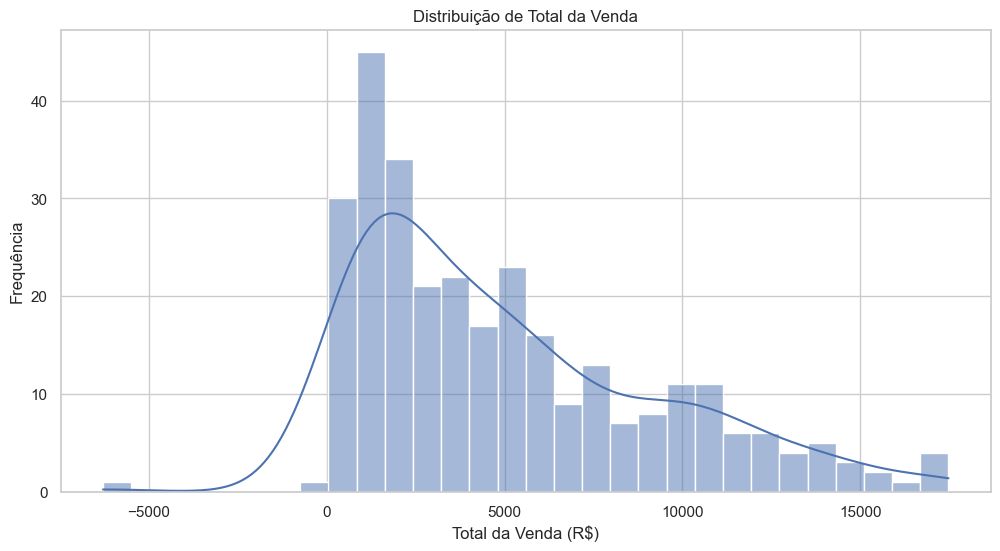

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df["total_venda"], bins=30, kde=True)
plt.title("Distribuição de Total da Venda")
plt.xlabel("Total da Venda (R$)")
plt.ylabel("Frequência")
plt.show()

O histograma indica que a variável `total_venda` apresenta uma distribuição
assimétrica à direita, com maior concentração de valores em faixas
mais baixas e uma cauda longa em direção a valores elevados.

Observa-se que a maioria das vendas está concentrada aproximadamente entre
R$ 1.000 e R$ 6.000, enquanto valores muito altos ocorrem com menor frequência,
caracterizando possíveis vendas atípicas.

Além disso, a presença de valores negativos no extremo esquerdo do gráfico
indica registros fora do padrão, que podem indicar anomalias.

A curva de densidade reforça a ausência de normalidade na distribuição.

### Boxplot de total_venda

O boxplot é útil para identificar outliers visualmente, que podem representar anomalias.

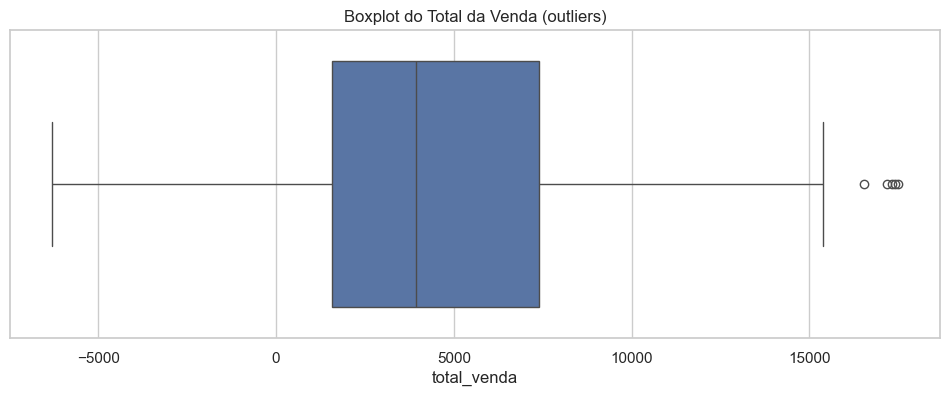

In [11]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=df["total_venda"])
plt.title("Boxplot do Total da Venda (outliers)")
plt.show()


O boxplot evidencia a concentração da maior parte das vendas em um intervalo
central, enquanto valores extremamente altos aparecem como pontos isolados à
direita do gráfico, caracterizando outliers.

A presença de valores negativos e a extensão desigual dos bigodes reforçam a
assimetria da distribuição e a alta variabilidade dos dados.

## Aplicação do detector de anomalias e resultados


In [12]:
dados_modelo = preparar_dados_modelo(df)
df["anomalia"] = detectar_anomalias(dados_modelo)

df["anomalia"].value_counts()
df[df["anomalia"] == 1].head()

,data,produto,quantidade,preco_unitario,total_venda,anomalia
20,2025-01-07,Teclado,-5,1258.99,-6294.95,1
30,2025-01-11,Mouse,9,1926.23,17336.07,1
35,2025-01-12,Teclado,1,0.00,0.00,1
41,2025-01-14,Mouse,9,1838.42,16545.78,1
130,2025-02-13,Monitor,9,1910.84,17197.56,1


### Total de anomalias detectadas

In [13]:
df["anomalia"].sum()

np.int64(6)

### Visualização final com anomalias


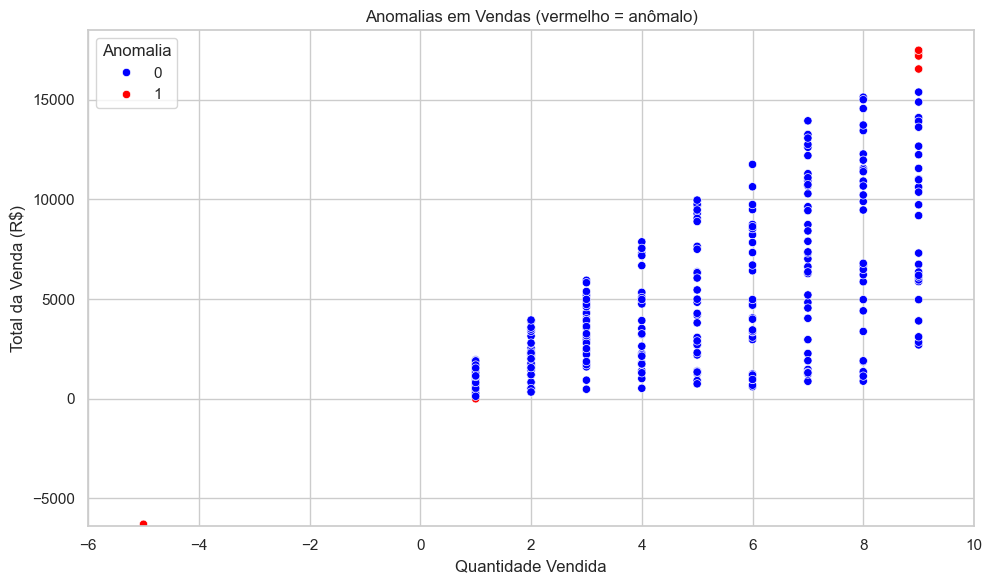

In [14]:
grafico_dispersao(df)

O gráfico de dispersão apresenta a relação entre a **quantidade vendida** e o **total da venda**.

Observa-se uma **tendência positiva** entre as variáveis: à medida que a quantidade vendida aumenta, o total da venda também tende a crescer. Esse comportamento é esperado, uma vez que o valor total da venda é diretamente influenciado pela quantidade de itens vendidos e pelo preço unitário.

Os pontos foram coloridos de acordo com a variável `anomalia`:
- **Pontos azuis** representam registros classificados como vendas normais.
- **Pontos vermelhos** indicam vendas identificadas como anômalas pelo modelo.

As anomalias aparecem em regiões distantes da concentração principal dos dados, destacando-se:
- Um registro com **quantidade negativa**, acompanhado de um valor de venda muito baixo, caracterizando um dado inconsistente.
- Registros com **valores de total da venda extremamente elevados** em comparação com a maioria dos dados, mesmo para quantidades semelhantes, indicando vendas atípicas.

A visualização confirma que o modelo de detecção de anomalias conseguiu identificar observações que fogem do padrão geral do conjunto de dados, reforçando a utilidade dessa abordagem para identificar comportamentos anormais nas vendas.
